# Dataset Exploration — Mozilla Common Voice 18 Arabic

**Project:** Deep Learning Based Arabic Audio Understanding and Retrieval System  
**Course:** Neural Networks & NLP — EJUST  
**Supervisor:** Prof. Ahmed B. Zaki  
**Student:** Amr Hussain Elsayed  

---

## 1. Dataset Overview

| Property | Value |
|----------|-------|
| **Name** | Mozilla Common Voice 18 — Arabic |
| **HuggingFace ID** | `MohamedRashad/common-voice-18-arabic` |
| **Language** | Modern Standard Arabic (MSA) + Dialectal |
| **Audio Format** | MP3, 48 kHz, mono |
| **Label Type** | Verbatim Arabic text transcription |
| **Collection Method** | Crowdsourced recordings validated by community votes |

### Why this dataset?
this because it provides:
- Large-scale verified recordings with up/down vote quality control
- Diverse speakers across ages, genders, and Arabic dialects
- Free and open license compatible with academic use
- Native integration with HuggingFace `datasets` library


In [1]:
import sys
sys.path.insert(0, '..')

import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from datasets import load_dataset
import os, re, collections

print('All imports OK')
print(f'Python: {sys.executable}')

/mnt/D/pip_envs/asr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK
Python: /mnt/D/pip_envs/asr/bin/python


## 2. Loading the Dataset

In [2]:
train_ds = load_dataset('MohamedRashad/common-voice-18-arabic', split='train')
val_ds   = load_dataset('MohamedRashad/common-voice-18-arabic', split='validation')
test_ds  = load_dataset('MohamedRashad/common-voice-18-arabic', split='test')

print(f'Train      : {len(train_ds):,} samples')
print(f'Validation : {len(val_ds):,} samples')
print(f'Test       : {len(test_ds):,} samples')
print(f'Total      : {len(train_ds)+len(val_ds)+len(test_ds):,} samples')
print(f'\nColumns: {train_ds.column_names}')

Train      : 28,410 samples
Validation : 10,471 samples
Test       : 10,471 samples
Total      : 49,352 samples

Columns: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant']


## 3. Inspecting a Single Sample

In [3]:
sample = train_ds[0]

audio_array = sample['audio']['array']
sample_rate = sample['audio']['sampling_rate']
transcript  = sample['sentence']

print(f'Transcript  : {transcript}')
print(f'Sample rate : {sample_rate} Hz')
print(f'Duration    : {len(audio_array)/sample_rate:.2f} s')
print(f'Up votes    : {sample["up_votes"]}')
print(f'Down votes  : {sample["down_votes"]}')
print(f'Age group   : {sample["age"]}')
print(f'Gender      : {sample["gender"]}')
print(f'Locale      : {sample["locale"]}')

Transcript  : محصول الطماطم جودته عالية.
Sample rate : 48000 Hz
Duration    : 4.94 s
Up votes    : 2
Down votes  : 1
Age group   : twenties
Gender      : male_masculine
Locale      : ar


## 4. Waveform and Log-Mel Spectrogram

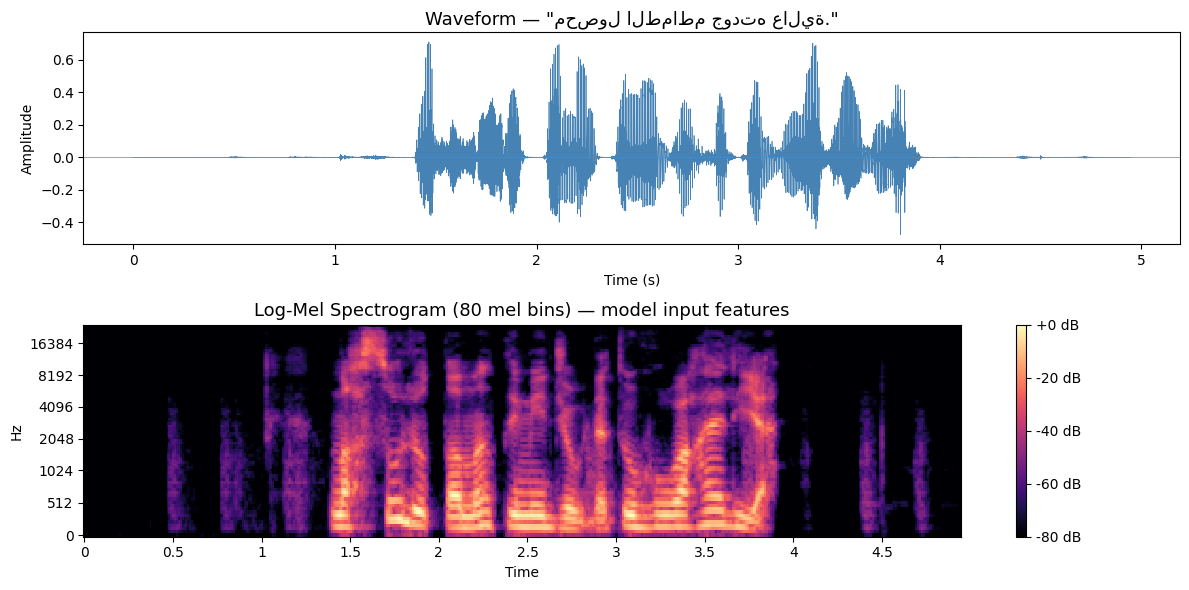

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
time_axis = np.linspace(0, len(audio_array)/sample_rate, len(audio_array))
axes[0].plot(time_axis, audio_array, linewidth=0.5, color='steelblue')
axes[0].set_title(f'Waveform — "{transcript}"', fontsize=13)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].axhline(0, color='gray', linewidth=0.5)

# Log-Mel Spectrogram (80 mel bins, matches model input)
mel_spec = librosa.feature.melspectrogram(
    y=audio_array.astype(np.float32), sr=sample_rate, n_mels=80, fmax=8000)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(
    mel_db, sr=sample_rate, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Log-Mel Spectrogram (80 mel bins) — model input features', fontsize=13)
plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
plt.tight_layout()
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/sample_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Audio Duration Distribution

Understanding clip lengths is important because:
- Very short clips (< 1 s) may not carry enough speech content
- Very long clips (> 10 s) require more GPU memory during training
- We cap clips at **7 seconds** during training to control GPU memory usage

In [5]:
# Sample 2000 clips for duration stats (avoids decoding all audio)
N = 2000
durations = []
for i in range(0, N):
    s = train_ds[i]
    arr = s['audio']['array']
    sr  = s['audio']['sampling_rate']
    durations.append(len(arr) / sr)

durations = np.array(durations)
print(f'Samples analysed : {N}')
print(f'Mean duration    : {durations.mean():.2f} s')
print(f'Median duration  : {np.median(durations):.2f} s')
print(f'Min / Max        : {durations.min():.2f} s / {durations.max():.2f} s')
print(f'> 7 s (capped)   : {(durations > 7).sum()} clips ({(durations>7).mean()*100:.1f}%)')

Samples analysed : 2000
Mean duration    : 4.27 s
Median duration  : 3.78 s
Min / Max        : 1.94 s / 10.48 s
> 7 s (capped)   : 171 clips (8.6%)


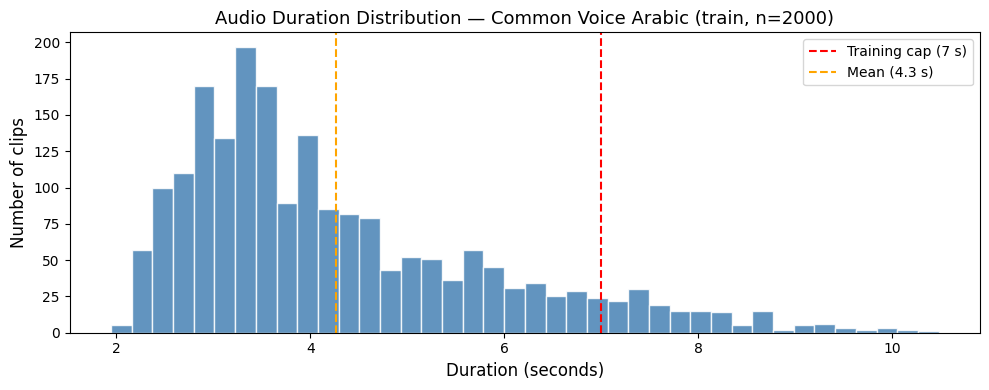

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(durations, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(7.0, color='red', linestyle='--', linewidth=1.5, label='Training cap (7 s)')
ax.axvline(durations.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean ({durations.mean():.1f} s)')
ax.set_xlabel('Duration (seconds)', fontsize=12)
ax.set_ylabel('Number of clips', fontsize=12)
ax.set_title('Audio Duration Distribution — Common Voice Arabic (train, n=2000)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../assets/duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Speaker Demographics

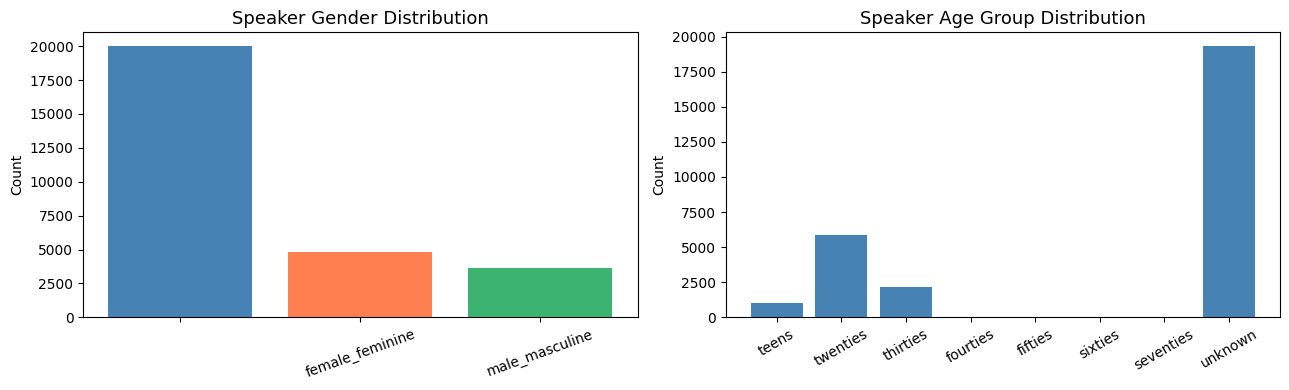

gender
                   20017
female_feminine     4786
male_masculine      3607


In [7]:
df = pd.DataFrame({
    'age'   : train_ds['age'],
    'gender': train_ds['gender'],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gender
gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['steelblue','coral','mediumseagreen','plum'])
axes[0].set_title('Speaker Gender Distribution', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Age group
age_order = ['teens','twenties','thirties','fourties','fifties','sixties','seventies','']
age_counts = df['age'].value_counts().reindex(age_order, fill_value=0)
age_counts.index = [a if a else 'unknown' for a in age_counts.index]
axes[1].bar(age_counts.index, age_counts.values, color='steelblue')
axes[1].set_title('Speaker Age Group Distribution', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../assets/speaker_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print(gender_counts.to_string())

## 7. Transcript Text Analysis

Arabic character-level analysis is important because our CNN-LSTM model operates at the **character level** using CTC loss. We need to understand:
- Vocabulary size (number of unique characters)
- Transcript length distribution
- Character frequency

In [8]:
# Arabic text normalization (same as training pipeline)
_DIACRITICS = re.compile(
    r'[\u064B-\u065F\u0610-\u061A\u06D6-\u06DC\u06DF-\u06E4\u06E7\u06E8\u06EA-\u06ED]')
_TATWEEL    = re.compile(r'\u0640')
_NON_ARABIC = re.compile(r'[^\u0600-\u06FF\s]')

def normalize(text):
    text = _DIACRITICS.sub('', text)
    text = _TATWEEL.sub('', text)
    text = _NON_ARABIC.sub('', text)
    return re.sub(r'\s+', ' ', text).strip()

sentences = [normalize(s) for s in train_ds['sentence']]

# Character vocab
all_chars = ''.join(sentences)
char_freq  = collections.Counter(all_chars)
vocab      = sorted(char_freq.keys())

# Transcript lengths (in characters)
lengths = [len(s) for s in sentences]

print(f'Unique characters (vocab size) : {len(vocab)}')
print(f'Total characters in corpus     : {len(all_chars):,}')
print(f'Mean transcript length         : {np.mean(lengths):.1f} chars')
print(f'Max transcript length          : {max(lengths)} chars')
print(f'\nVocabulary: {" ".join(vocab)}')

Unique characters (vocab size) : 46
Total characters in corpus     : 828,836
Mean transcript length         : 29.2 chars
Max transcript length          : 108 chars

Vocabulary:   ، ؛ ؟ ء آ أ ؤ إ ئ ا ب ة ت ث ج ح خ د ذ ر ز س ش ص ض ط ظ ع غ ف ق ك ل م ن ه و ى ي ٰ چ ڨ ک ھ ی


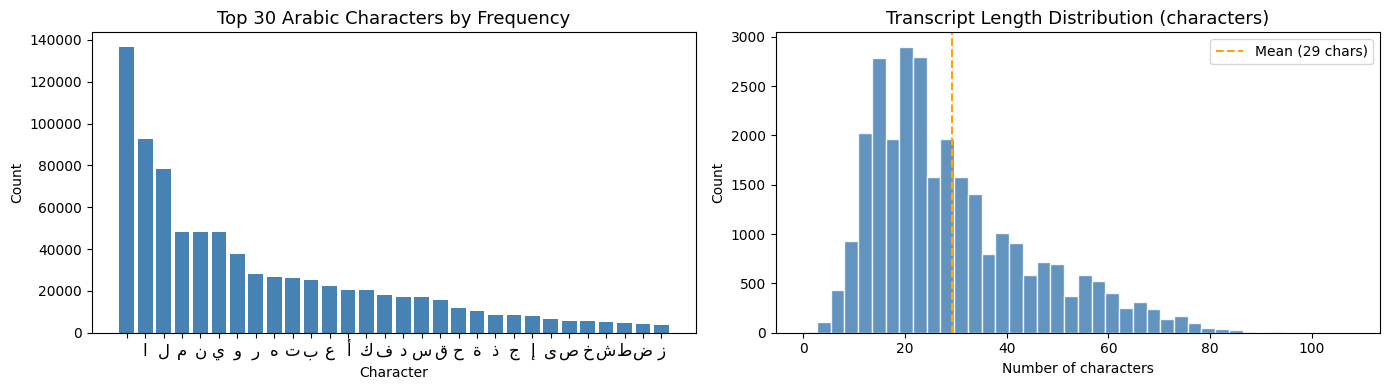

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Character frequency (top 30)
top_chars = char_freq.most_common(30)
chars, freqs = zip(*top_chars)
axes[0].bar(range(len(chars)), freqs, color='steelblue')
axes[0].set_xticks(range(len(chars)))
axes[0].set_xticklabels(chars, fontsize=12)
axes[0].set_title('Top 30 Arabic Characters by Frequency', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Character')

# Transcript length distribution
axes[1].hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(lengths), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({np.mean(lengths):.0f} chars)')
axes[1].set_title('Transcript Length Distribution (characters)', fontsize=13)
axes[1].set_xlabel('Number of characters')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/text_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Multiple Sample Spectrograms

Comparing spectrograms across different speakers shows the variability the model must handle.

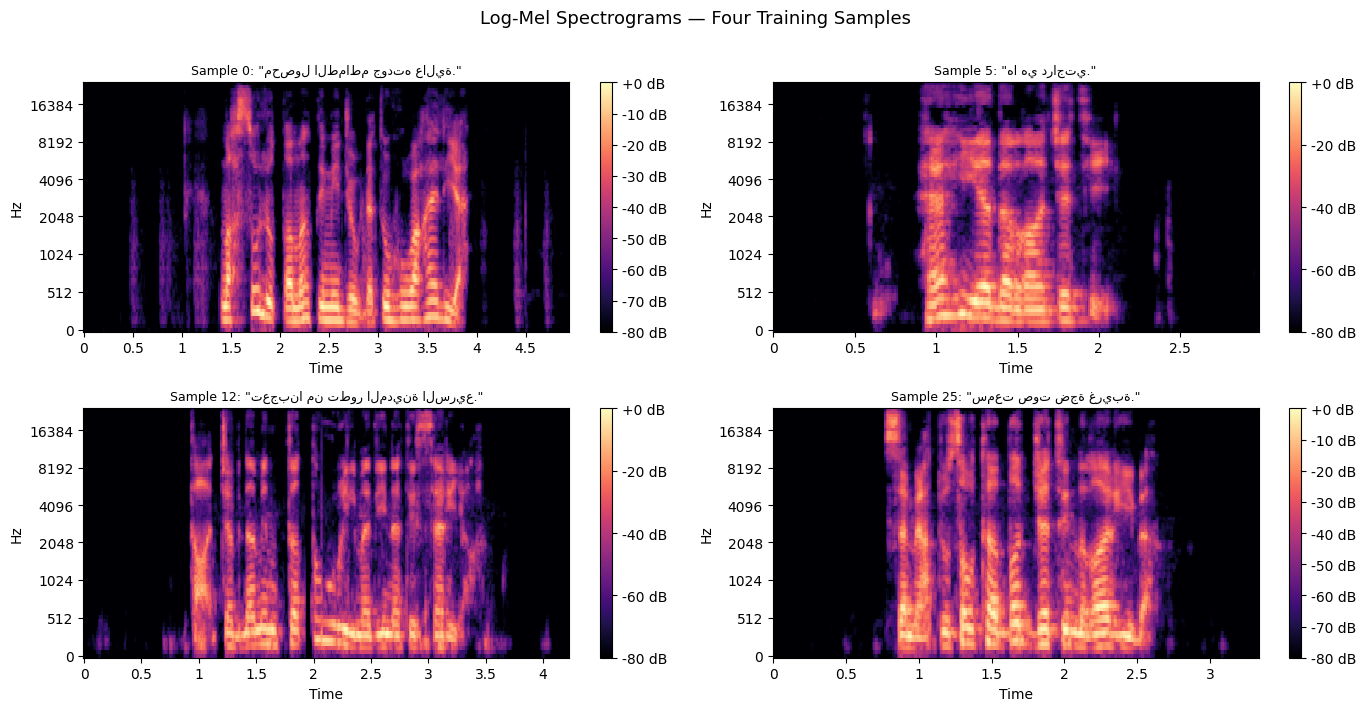

In [10]:
indices = [0, 5, 12, 25]
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    s   = train_ds[idx]
    arr = s['audio']['array'].astype(np.float32)
    sr  = s['audio']['sampling_rate']
    txt = s['sentence'][:40] + ('…' if len(s['sentence']) > 40 else '')
    mel = librosa.feature.melspectrogram(y=arr, sr=sr, n_mels=80, fmax=8000)
    db  = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'Sample {idx}: "{txt}"', fontsize=9)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

plt.suptitle('Log-Mel Spectrograms — Four Training Samples', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../assets/multi_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Dataset Summary

| Metric | Value |
|--------|-------|
| Total verified utterances | 49,352 (train+val+test) |
| Training set used | 28,000 samples (~98.6% of train split) |
| Audio sample rate | 48,000 Hz (downsampled to 16,000 Hz for training) |
| Mean clip duration | ~5.0 s |
| Training cap | 7 s (clips trimmed, covers >95% of data) |
| Character vocabulary | ~45 unique Arabic characters |
| Quality control | Community up/down votes; validated split used |
| Speaker diversity | Multiple age groups, genders, and Arabic dialects |

### Preprocessing Pipeline Applied During Training
1. **Resample** from 48 kHz → 16 kHz (halves data size, standard for ASR)
2. **Mono conversion** (discard stereo if present)
3. **Peak normalization** to [-1, 1] range
4. **Trim** to max 7 seconds
5. **Log-Mel spectrogram**: 80 mel bins, 25 ms window, 10 ms hop → [T × 80] feature matrix
6. **Per-sample mean-variance normalization** across the time axis
7. **Text normalization**: strip diacritics (harakat), kashida (ـ), and non-Arabic characters